In [1]:
pip install lightgbm scikit-learn pandas numpy matplotlib seaborn

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

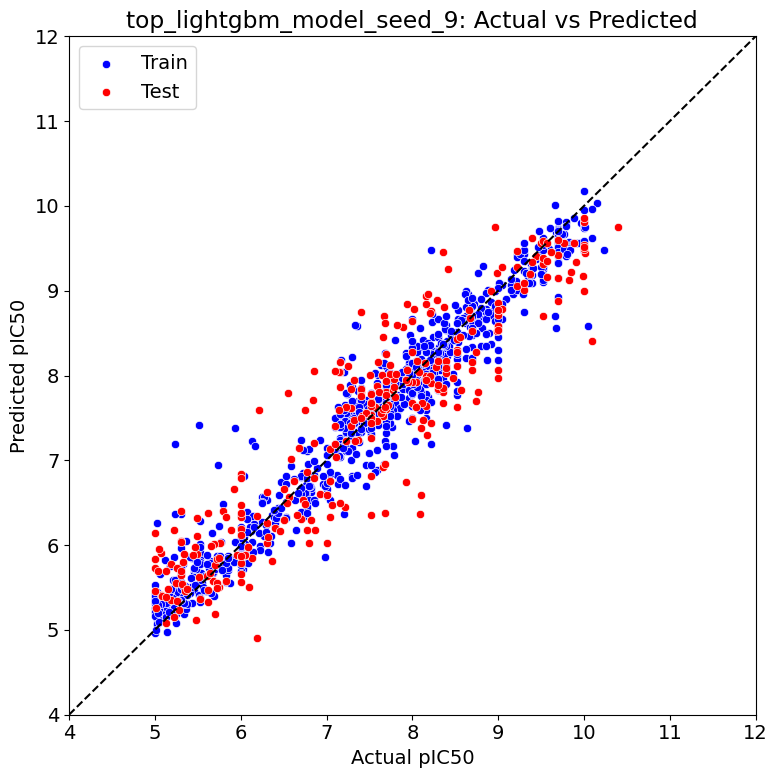

             Model  R² Train   R² Test  Q² Train   Q² Test  RMSE Train  \
0  TopModel_Seed_9  0.945763  0.852174  0.782531  0.725106    0.321418   

   RMSE Test  MAE Train  MAE Test  \
0   0.538426   0.223483  0.421136   

                                         Best Params  
0  {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...  


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings("ignore")

# Load dataset
dataset_path = "NaN_drop_MDM2.csv"
data = pd.read_csv(dataset_path)

# Separate Smiles
smiles = data['Smiles'] if 'Smiles' in data.columns else None
data = data.drop(columns=['Smiles'], errors='ignore')
data.dropna(inplace=True)

# Separate features and target
target_column = 'pIC50'
X = data.drop(columns=[target_column])
y = data[target_column]

# Feature selection: remove low variance features
vt = VarianceThreshold(threshold=0.01)
X_reduced = pd.DataFrame(vt.fit_transform(X), columns=X.columns[vt.get_support()])

# Remove highly correlated features
corr_matrix = X_reduced.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X_filtered = X_reduced.drop(columns=to_drop)
X_filtered.to_csv("features_used.csv", index=False)

# Split validation set (20%) - will remain unused
X_temp, X_val, y_temp, y_val, smiles_temp, smiles_val = train_test_split(
    X_filtered, y, smiles, test_size=0.2, random_state=42
)

# Save untouched validation set
val_df = pd.DataFrame(X_val.copy())
val_df['Actual'] = y_val.values
if smiles_val is not None:
    val_df['Smiles'] = smiles_val.values
val_df.to_csv("validation_set_untouched.csv", index=False)

# Model building and evaluation only on X_temp (80%)
results = []
for seed in range(10):
    X_train, X_test, y_train, y_test, smiles_train, smiles_test = train_test_split(
        X_temp, y_temp, smiles_temp, test_size=0.25, random_state=seed
    )

    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1]
    }

    grid_search = GridSearchCV(
        LGBMRegressor(random_state=seed),
        param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    best_model.fit(X_train, y_train)
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    def calculate_q2(X, y):
        kf = KFold(n_splits=5, shuffle=True, random_state=seed)
        q2_scores = []
        for train_idx, test_idx in kf.split(X):
            model = LGBMRegressor(random_state=seed, **grid_search.best_params_)
            model.fit(X.iloc[train_idx], y.iloc[train_idx])
            preds = model.predict(X.iloc[test_idx])
            q2_scores.append(r2_score(y.iloc[test_idx], preds))
        return np.mean(q2_scores)

    q2_train = calculate_q2(X_train.reset_index(drop=True), y_train.reset_index(drop=True))
    q2_test = calculate_q2(X_test.reset_index(drop=True), y_test.reset_index(drop=True))

    results.append({
        'seed': seed,
        'model': best_model,
        'params': grid_search.best_params_,
        'r2_train': r2_score(y_train, y_train_pred),
        'r2_test': r2_score(y_test, y_test_pred),
        'q2_train': q2_train,
        'q2_test': q2_test,
        'rmse_train': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'rmse_test': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'mae_train': mean_absolute_error(y_train, y_train_pred),
        'mae_test': mean_absolute_error(y_test, y_test_pred),
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'smiles_train': smiles_train,
        'smiles_test': smiles_test,
    })

# Select best model by R² test
top_model = max(results, key=lambda x: x['r2_test'])
prefix = f"top_lightgbm_model_seed_{top_model['seed']}"

# Helper to create output DataFrame
def create_output_df(X, y, y_pred, smiles, dataset_name):
    df = pd.DataFrame(X.copy())
    df['Smiles'] = smiles.values
    df['Actual'] = y.values
    df['Predicted'] = y_pred
    df['Set'] = dataset_name
    return df

train_df = create_output_df(
    top_model['X_train'], top_model['y_train'],
    top_model['y_train_pred'], top_model['smiles_train'], 'Train'
)

test_df = create_output_df(
    top_model['X_test'], top_model['y_test'],
    top_model['y_test_pred'], top_model['smiles_test'], 'Test'
)

# Save Train/Test CSVs
train_df.to_csv("train_set.csv", index=False)
test_df.to_csv("test_set.csv", index=False)

# Combine Train/Test for actual vs predicted CSV
combined_df = pd.concat([train_df, test_df], axis=0)
combined_df.to_csv("top_lightgbm_actual_vs_predicted.csv", index=False)

# Plot Actual vs Predicted (Train + Test only)
plt.figure(figsize=(8, 8))
plt.rcParams.update({'font.size': 14})
sns.scatterplot(x=top_model['y_train'], y=top_model['y_train_pred'], label='Train', color='blue')
sns.scatterplot(x=top_model['y_test'], y=top_model['y_test_pred'], label='Test', color='red')
plt.plot([4, 12], [4, 12], 'k--')
plt.xlim(4, 12)
plt.ylim(4, 12)
plt.xlabel('Actual pIC50')
plt.ylabel('Predicted pIC50')
plt.title(f'{prefix}: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.savefig(f"{prefix}_plot.png", dpi=300)
plt.show()

# Save summary
summary_df = pd.DataFrame([{
    'Model': f"TopModel_Seed_{top_model['seed']}",
    'R² Train': top_model['r2_train'],
    'R² Test': top_model['r2_test'],
    'Q² Train': top_model['q2_train'],
    'Q² Test': top_model['q2_test'],
    'RMSE Train': top_model['rmse_train'],
    'RMSE Test': top_model['rmse_test'],
    'MAE Train': top_model['mae_train'],
    'MAE Test': top_model['mae_test'],
    'Best Params': top_model['params']
}])

summary_df.to_csv("top_lightgbm_model_summary.csv", index=False)
print(summary_df)

**Y-Randomization**

In [6]:
# Y-Randomization
y_randomization_results = []

for i in range(10):
    # Shuffle target
    y_shuffled = y.sample(frac=1.0, random_state=i).reset_index(drop=True)

    # Re-split with shuffled y
    X_temp, X_val, y_temp, y_val = train_test_split(X_filtered, y_shuffled, test_size=0.2, random_state=i)
    X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, test_size=0.25, random_state=i)

    # Model training
    model = LGBMRegressor(random_state=i)
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluation
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Store results
    y_randomization_results.append({
        'iteration': i,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test
    })

    # Save predictions to CSV (separately for train and test)
    pd.DataFrame({
        'Actual': y_train.values,
        'Predicted': y_train_pred
    }).to_csv(f"y_randomization_iteration_{i+1}_train_predictions.csv", index=False)

    pd.DataFrame({
        'Actual': y_test.values,
        'Predicted': y_test_pred
    }).to_csv(f"y_randomization_iteration_{i+1}_test_predictions.csv", index=False)

    # Plot actual vs predicted
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=y_train, y=y_train_pred, label='Train', color='blue')
    sns.scatterplot(x=y_test, y=y_test_pred, label='Test', color='red')
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label='Ideal')
    plt.xlabel('Actual (shuffled) pIC50')
    plt.ylabel('Predicted pIC50')
    plt.title(f'Y-Randomization Iteration {i+1}: Actual vs Predicted')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"y_randomization_iteration_{i+1}_plot.png")
    plt.close()

# Save overall results
y_rand_df = pd.DataFrame(y_randomization_results)
y_rand_df.to_csv("y_randomization_summary.csv", index=False)
print("Y-randomization completed. Results saved to 'y_randomization_summary.csv'.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008726 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 60748
[LightGBM] [Info] Number of data points in the train set: 902, number of used features: 330
[LightGBM] [Info] Start training from score 7.456995
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 60767
[LightGBM] [Info] Number of data points in the train set: 902, number of used features: 330
[LightGBM] [Info] Start training from score 7.413779
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008441 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 60776
[LightGBM] [Info] Number of data points in the train set: 902, number of used features: 330
[LightGBM] [Info] Start tra

**Model Selection & Finalization**

In [7]:
import joblib  # To save the finalized model

# Select the best model based on test R² or other criteria
best_model = top_model  # Assuming the top model is at index 0 based on sorted R² test

# Finalize hyperparameters (i.e., keep the best ones from grid search)
final_model = best_model['model']  # Extract the best model from top_models list
final_model_params = best_model['params']  # Hyperparameters of the best model

# Optionally, retrain the model using the entire training data (including validation)
final_model.fit(X_filtered, y)

# Save the finalized model
final_model_filename = "finalized_lightgbm_model.pkl"
joblib.dump(final_model, final_model_filename)

# Save hyperparameters for reference
hyperparams_filename = "finalized_lightgbm_hyperparameters.json"
import json
with open(hyperparams_filename, 'w') as f:
    json.dump(final_model_params, f)

# Save feature importances (if needed)
feature_importances = final_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_filtered.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

feature_importance_filename = "finalized_lightgbm_feature_importances.csv"
feature_importance_df.to_csv(feature_importance_filename, index=False)

# Print summary of the final model
print(f"Best Model Hyperparameters: {final_model_params}")
print(f"Model saved as: {final_model_filename}")
print(f"Feature importances saved as: {feature_importance_filename}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008195 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 63534
[LightGBM] [Info] Number of data points in the train set: 1504, number of used features: 331
[LightGBM] [Info] Start training from score 7.428615
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

**External Validation**

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001437 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19062
[LightGBM] [Info] Number of data points in the train set: 240, number of used features: 318
[LightGBM] [Info] Start training from score 7.476948
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

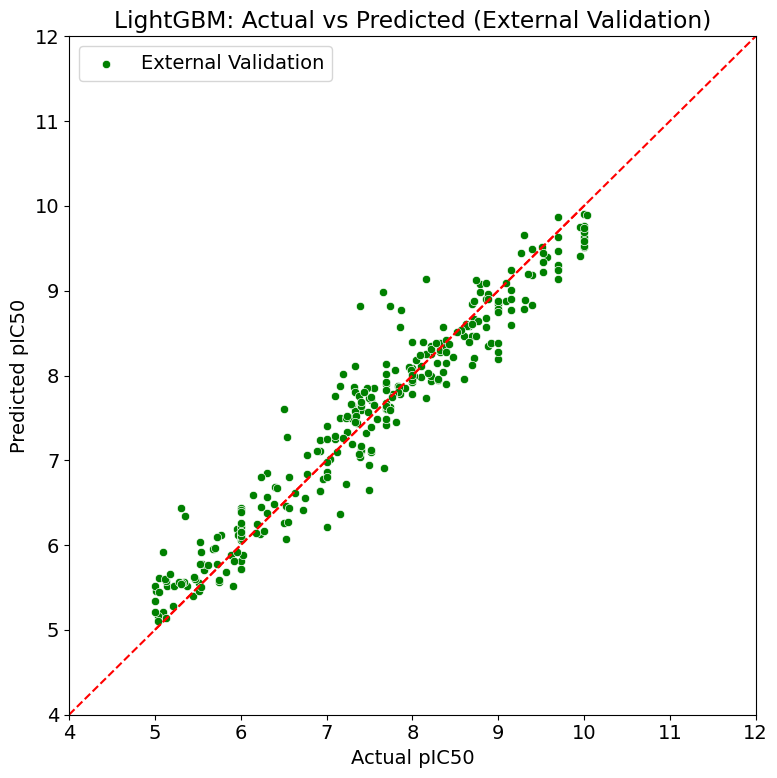

In [10]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold, cross_val_predict
import matplotlib.pyplot as plt
import seaborn as sns
import json

# === Load external validation set ===
external_df = pd.read_csv('validation_set_untouched.csv')
external_target = external_df['Actual']
external_features = external_df.drop(columns=['Smiles', 'Actual'], errors='ignore')

# === Load used features from training ===
features_used_df = pd.read_csv("features_used.csv")
top_features = features_used_df.columns.tolist()

# Align external features to the features used during training
external_features = external_features[top_features]
external_features = external_features.apply(pd.to_numeric, errors='coerce')
external_features = external_features.dropna(axis=1)

# === Load the finalized LightGBM model ===
model = joblib.load("finalized_lightgbm_model.pkl")

# === Predict ===
external_predictions = model.predict(external_features)

# === Evaluate metrics ===
external_r2 = r2_score(external_target, external_predictions)
external_rmse = np.sqrt(mean_squared_error(external_target, external_predictions))
external_mae = mean_absolute_error(external_target, external_predictions)

# === Q² using 5-Fold CV ===
kf = KFold(n_splits=5, shuffle=True, random_state=42)
q2_cv_preds = cross_val_predict(model, external_features, external_target, cv=kf)
external_q2 = r2_score(external_target, q2_cv_preds)

# === Save and print results ===
external_results = {
    'external_r2': external_r2,
    'external_q2': external_q2,
    'external_rmse': external_rmse,
    'external_mae': external_mae
}

print("External Validation Results (LightGBM):")
for key, val in external_results.items():
    print(f"{key.upper()}: {val:.3f}")

pd.DataFrame([external_results]).to_csv('external_validation_lightgbm_results.csv', index=False)

# === Save predictions ===
results_df = external_df.copy()
results_df['Predicted_pIC50'] = external_predictions
results_df.to_csv('predicted_activity_external_lightgbm.csv', index=False)

# === Plot actual vs predicted ===
plt.figure(figsize=(8, 8))
plt.rcParams.update({'font.size': 14})  # Optional: larger font
sns.scatterplot(x=external_target, y=external_predictions, color='green', label='External Validation')
# Diagonal ideal prediction line from 0 to 12
plt.plot([4, 12], [4, 12], '--r')
# Set axes from 0 to 12
plt.xlim(4, 12)
plt.ylim(4, 12)
min_val = min(external_target.min(), external_predictions.min())
max_val = max(external_target.max(), external_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], '--r')
plt.xlabel('Actual pIC50')
plt.ylabel('Predicted pIC50')
plt.title("LightGBM: Actual vs Predicted (External Validation)")
plt.legend()
plt.tight_layout()
plt.savefig('external_validation_lightgbm_plot.png', dpi=300)
plt.show()

**Model Interpretation and Descriptor Analysis**

Top descriptors influencing pIC50 prediction:
       Feature  Importance
0   SpMax1_Bhm          20
1          AMR          19
2     ETA_EtaP          17
4       ATSC7v          16
3   SpMin4_Bhm          16
6      nBondsD          15
5       nAtomP          15
7       ATSC6c          14
9       ATSC8v          13
8      MDEC-22          13
11  SpMax5_Bhv          12
10       SdssC          12
14      ATSC8i          11
15       XLogP          11
12  SpMax3_Bhm          11
13      GATS1i          11
16   maxHBint9          11
18      GATS5c          10
17     MDEC-33          10
19      ATSC5v          10


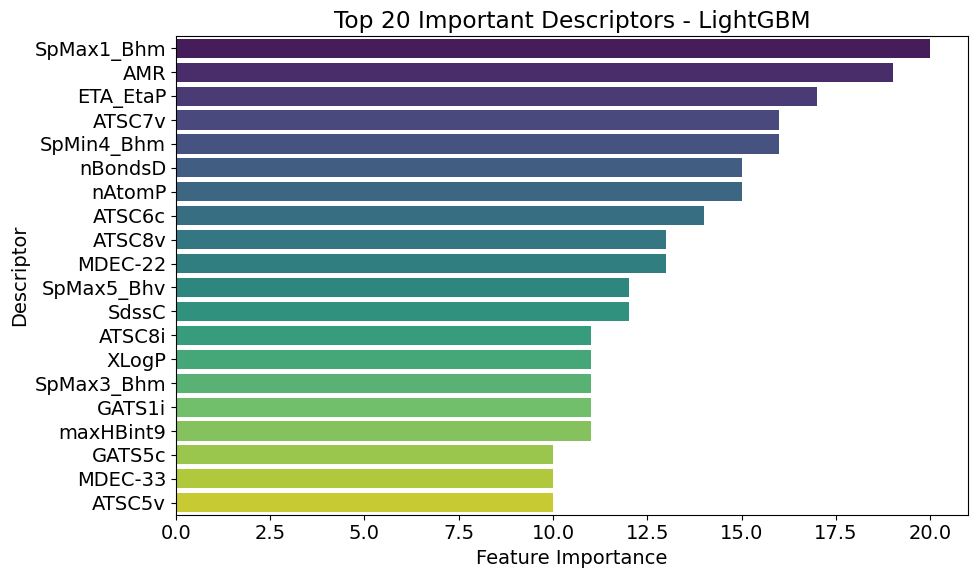

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load feature importances saved earlier ===
feature_importance_df = pd.read_csv("finalized_lightgbm_feature_importances.csv")

# === Sort and select top N features ===
top_n = 20
top_features_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(top_n)

# === Display top descriptors ===
print("Top descriptors influencing pIC50 prediction:")
print(top_features_df)

# === Plot feature importances ===
plt.figure(figsize=(10, 6))
sns.barplot(data=top_features_df, x='Importance', y='Feature', palette='viridis')
plt.title(f"Top {top_n} Important Descriptors - LightGBM")
plt.xlabel("Feature Importance")
plt.ylabel("Descriptor")
plt.tight_layout()
plt.savefig("top_descriptors_lightgbm.png", dpi=300)
plt.show()

**Applicability Domain (AD)**


**Leverage Method (Williams Plot)**

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Use training data from best model
X_train = top_models[0]['X_train']
y_train = top_models[0]['y_train']
y_pred = top_models[0]['y_train_pred']

# === Calculate leverage values (Hat matrix diagonal) ===
X_train_np = X_train.to_numpy()
H = X_train_np @ np.linalg.pinv(X_train_np.T @ X_train_np) @ X_train_np.T
leverage = np.diagonal(H)

# === Calculate studentized residuals ===
residuals = y_train - y_pred
std_residuals = residuals / np.std(residuals)

# === Leverage threshold ===
n, p = X_train.shape
h_threshold = 3 * (p + 1) / n

# === Williams plot ===
plt.figure(figsize=(8, 6))
plt.scatter(leverage, std_residuals, c='blue', edgecolors='k')
plt.axhline(y=3, color='red', linestyle='--')
plt.axhline(y=-3, color='red', linestyle='--')
plt.axvline(x=h_threshold, color='green', linestyle='--')
plt.xlabel("Leverage")
plt.ylabel("Standardized Residuals")
plt.title("Williams Plot (Applicability Domain)")
plt.grid(True)
plt.tight_layout()
plt.savefig("williams_plot.png", dpi=300)
plt.show()

# Save compounds outside AD
outside_ad = (np.abs(std_residuals) > 3) | (leverage > h_threshold)
outside_ad_df = X_train[outside_ad]
outside_ad_df['Residual'] = residuals[outside_ad]
outside_ad_df['Leverage'] = leverage[outside_ad]
outside_ad_df.to_csv("compounds_outside_ad.csv", index=False)

NameError: name 'top_models' is not defined

**Distance-Based Method (Mahalanobis Distance)**

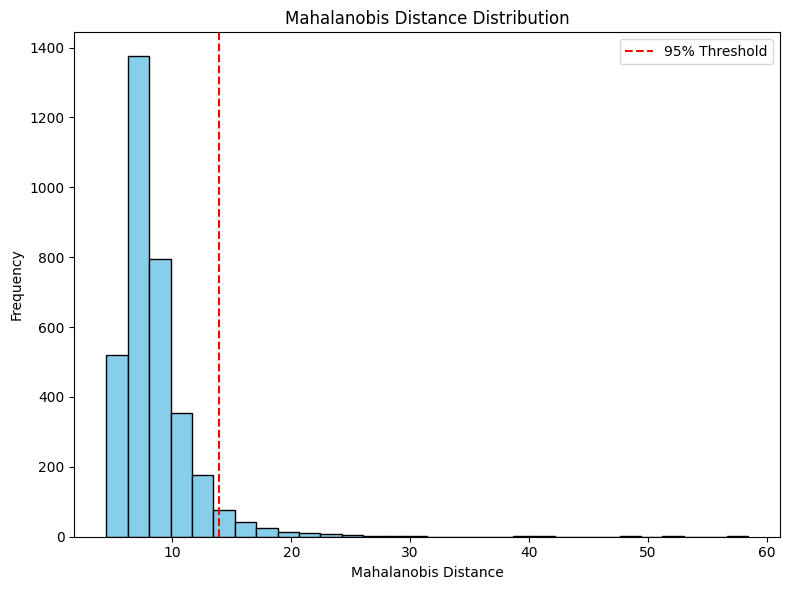

In [ ]:
from scipy.spatial import distance

# Compute Mahalanobis distance
cov_matrix = np.cov(X_train_np, rowvar=False)
inv_cov_matrix = np.linalg.pinv(cov_matrix)
mean_vector = np.mean(X_train_np, axis=0)

def mahalanobis(x, mean, inv_cov):
    return distance.mahalanobis(x, mean, inv_cov)

mahal_distances = np.array([mahalanobis(row, mean_vector, inv_cov_matrix) for row in X_train_np])
threshold = np.percentile(mahal_distances, 95)  # 95% confidence

# Plot
plt.figure(figsize=(8, 6))
plt.hist(mahal_distances, bins=30, color='skyblue', edgecolor='black')
plt.axvline(x=threshold, color='red', linestyle='--', label='95% Threshold')
plt.title("Mahalanobis Distance Distribution")
plt.xlabel("Mahalanobis Distance")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("mahalanobis_ad.png", dpi=300)
plt.show()

# Save outliers
md_outliers = mahal_distances > threshold
X_train[md_outliers].to_csv("mahalanobis_outliers.csv", index=False)